# CNN Fake Reviews Detection - Preprocessing & Training

Notebook này tập trung vào việc tiền xử lý dữ liệu và huấn luyện mô hình CNN cho bài toán phát hiện đánh giá giả.

## Mục tiêu:
1. **Tiền xử lý dữ liệu** phù hợp cho CNN
2. **Tokenization và Padding** cho text sequences
3. **Xây dựng và huấn luyện** mô hình CNN
4. **Đánh giá hiệu suất** và so sánh với các mô hình khác

## 1. Import Libraries và Setup

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import pickle
import os
import time
from collections import Counter

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Download required NLTK data
nltk.download('stopwords', quiet=True)

# Settings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Set style for better visualization
sns.set_style("whitegrid")
plt.style.use('default')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load và Explore Dataset

In [2]:
# Load the dataset
dataset_path = "Preprocessed Fake Reviews Detection Dataset.csv"
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Dataset shape: (40432, 5)

First 5 rows:


,Unnamed: 0,category,rating,label,text_
0,0,Home_and_Kitchen_5,5.0,CG,love well made sturdi comfort i love veri pretti
1,1,Home_and_Kitchen_5,5.0,CG,love great upgrad origin i 've mine coupl year
2,2,Home_and_Kitchen_5,5.0,CG,thi pillow save back i love look feel pillow
3,3,Home_and_Kitchen_5,1.0,CG,miss inform use great product price i
4,4,Home_and_Kitchen_5,5.0,CG,veri nice set good qualiti we set two month


In [3]:
# Basic information about the dataset
print("Dataset Information:")
print("=" * 50)
df.info()

print("\nMissing Values Analysis:")
print("=" * 30)
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  40432 non-null  int64  
 1   category    40432 non-null  object 
 2   rating      40432 non-null  float64
 3   label       40432 non-null  object 
 4   text_       40431 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.5+ MB

Missing Values Analysis:
Missing values per column:
Unnamed: 0    0
category      0
rating        0
label         0
text_         1
dtype: int64

Total missing values: 1
Duplicate rows: 0


## 3. Data Cleaning và Preprocessing

In [4]:
# Clean the data
print("🧹 Cleaning dataset...")

# Remove unnamed columns if exists
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
    print("✓ Removed 'Unnamed: 0' column")

# Remove any remaining missing values
initial_shape = df.shape
df.dropna(inplace=True)
print(f"✓ Removed {initial_shape[0] - df.shape[0]} rows with missing values")

# Add text length feature for analysis
df['text_length'] = df['text_'].apply(len)
print("✓ Added text_length feature")

print("\nData cleaning completed!")
print(f"Final dataset shape: {df.shape}")
df.head()

🧹 Cleaning dataset...
✓ Removed 'Unnamed: 0' column
✓ Removed 1 rows with missing values
✓ Added text_length feature

Data cleaning completed!
Final dataset shape: (40431, 5)


,category,rating,label,text_,text_length
0,Home_and_Kitchen_5,5.0,CG,love well made sturdi comfort i love veri pretti,48
1,Home_and_Kitchen_5,5.0,CG,love great upgrad origin i 've mine coupl year,46
2,Home_and_Kitchen_5,5.0,CG,thi pillow save back i love look feel pillow,44
3,Home_and_Kitchen_5,1.0,CG,miss inform use great product price i,37
4,Home_and_Kitchen_5,5.0,CG,veri nice set good qualiti we set two month,43


## 4. Analyze Label Distribution

🏷️ Analyzing label distribution...
Label Distribution:
label
OR    20216
CG    20215
Name: count, dtype: int64

Label proportions:
label
OR    0.5
CG    0.5
Name: proportion, dtype: float64


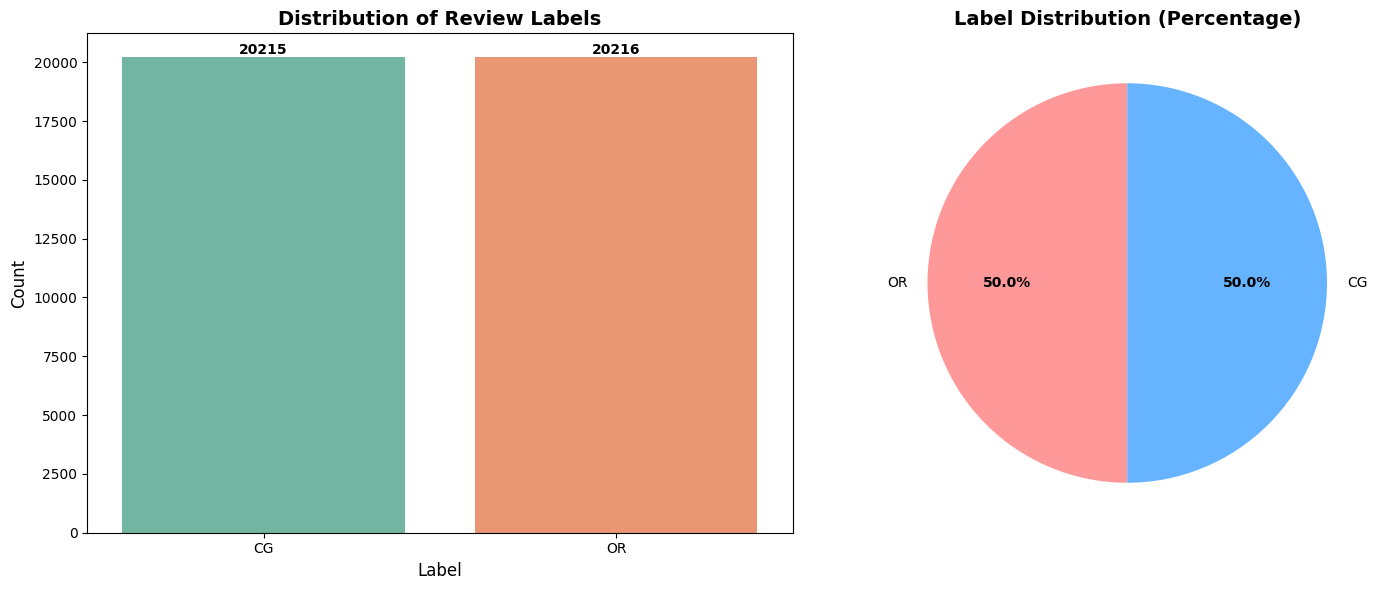

In [5]:
# Analyze label distribution
print("🏷️ Analyzing label distribution...")

label_counts = df['label'].value_counts()
print("Label Distribution:")
print("=" * 20)
print(label_counts)
print(f"\nLabel proportions:")
print(df['label'].value_counts(normalize=True).round(4))

# Visualize label distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
sns.countplot(data=df, x='label', palette='Set2', ax=ax1)
ax1.set_title('Distribution of Review Labels', fontsize=14, fontweight='bold')
ax1.set_xlabel('Label', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)

# Add count labels on bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#FF9999', '#66B3FF']
wedges, texts, autotexts = ax2.pie(label_counts.values, labels=label_counts.index, 
                                  colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Label Distribution (Percentage)', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

## 5. Text Preprocessing cho CNN

In [6]:
# Text preprocessing function cho CNN
def preprocess_text_for_cnn(text):
    """
    Preprocess text cho CNN:
    1. Convert to lowercase
    2. Remove punctuation
    3. Remove extra whitespace
    4. Basic cleaning
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

print("🧹 Preprocessing text data for CNN...")

# Apply preprocessing
df['text_cleaned'] = df['text_'].apply(preprocess_text_for_cnn)
print("✓ Text preprocessing completed!")

# Show examples
print("\n📝 Text preprocessing examples:")
for i in range(3):
    print(f"\nOriginal {i+1}:")
    print(df['text_'].iloc[i][:100] + "...")
    print(f"\nCleaned {i+1}:")
    print(df['text_cleaned'].iloc[i][:100] + "...")

🧹 Preprocessing text data for CNN...
✓ Text preprocessing completed!

📝 Text preprocessing examples:

Original 1:
love well made sturdi comfort i love veri pretti...

Cleaned 1:
love well made sturdi comfort i love veri pretti...

Original 2:
love great upgrad origin i 've mine coupl year...

Cleaned 2:
love great upgrad origin i ve mine coupl year...

Original 3:
thi pillow save back i love look feel pillow...

Cleaned 3:
thi pillow save back i love look feel pillow...


## 6. Analyze Text Length Distribution

📊 Text Length Analysis:
Original text length - Mean: 205.8, Max: 2232
Cleaned text length - Mean: 202.4, Max: 1996


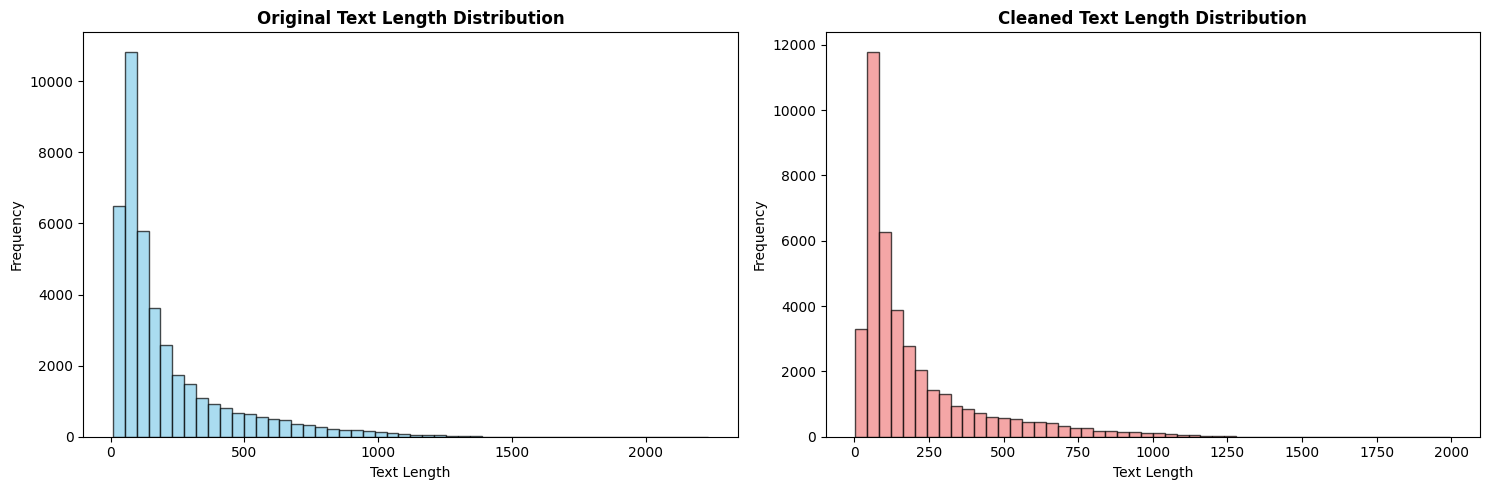

In [7]:
# Analyze text length distribution
print("📊 Text Length Analysis:")
print("=" * 30)

df['cleaned_text_length'] = df['text_cleaned'].apply(len)

print(f"Original text length - Mean: {df['text_length'].mean():.1f}, Max: {df['text_length'].max()}")
print(f"Cleaned text length - Mean: {df['cleaned_text_length'].mean():.1f}, Max: {df['cleaned_text_length'].max()}")

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original text length
axes[0].hist(df['text_length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('Original Text Length Distribution', fontweight='bold')
axes[0].set_xlabel('Text Length')
axes[0].set_ylabel('Frequency')

# Cleaned text length
axes[1].hist(df['cleaned_text_length'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].set_title('Cleaned Text Length Distribution', fontweight='bold')
axes[1].set_xlabel('Text Length')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 7. Tokenization và Sequence Preparation cho CNN

In [8]:
# CNN Parameters
MAX_WORDS = 10000  # Vocabulary size
MAX_LEN = 200      # Maximum sequence length
EMBEDDING_DIM = 100

print(f"⚙️ CNN Parameters:")
print(f"• Max words: {MAX_WORDS:,}")
print(f"• Max sequence length: {MAX_LEN}")
print(f"• Embedding dimension: {EMBEDDING_DIM}")

⚙️ CNN Parameters:
• Max words: 10,000
• Max sequence length: 200
• Embedding dimension: 100


In [10]:
# Tokenization
print("🔤 Tokenizing text data...")

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_cleaned'])

print(f"✓ Vocabulary size: {len(tokenizer.word_index):,}")
# print(f"✓ Total words: {tokenizer.word_counts.most_common(1)[0][1]:,}")

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['text_cleaned'])
print(f"✓ Converted {len(sequences)} texts to sequences")

# Pad sequences
X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
print(f"✓ Padded sequences shape: {X_padded.shape}")

# Show examples
print("\n📝 Tokenization examples:")
for i in range(2):
    print(f"\nText {i+1}:")
    print(df['text_cleaned'].iloc[i][:100] + "...")
    print(f"\nSequence {i+1}:")
    print(sequences[i][:20])
    print(f"\nPadded sequence {i+1}:")
    print(X_padded[i][:20])

🔤 Tokenizing text data...
✓ Vocabulary size: 34,565
✓ Converted 40431 texts to sequences
✓ Padded sequences shape: (40431, 200)

📝 Tokenization examples:

Text 1:
love well made sturdi comfort i love veri pretti...

Sequence 1:
[5, 18, 50, 150, 67, 2, 5, 136, 108]

Padded sequence 1:
[  5  18  50 150  67   2   5 136 108   0   0   0   0   0   0   0   0   0
   0   0]

Text 2:
love great upgrad origin i ve mine coupl year...

Sequence 2:
[5, 8, 1266, 328, 2, 56, 601, 132, 43]

Padded sequence 2:
[   5    8 1266  328    2   56  601  132   43    0    0    0    0    0
    0    0    0    0    0    0]


## 8. Prepare Labels và Split Data

In [11]:
# Prepare labels
print("🏷️ Preparing labels...")

# Create label mapping
label_map = {'OR': 0, 'CG': 1}  # OR: Original, CG: Computer Generated
y = df['label'].map(label_map).values

print(f"✓ Labels shape: {y.shape}")
print(f"✓ Label distribution: {np.bincount(y)}")
print(f"✓ Label mapping: {label_map}")

# Split data
print("\n✂️ Splitting data...")

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Data split completed:")
print(f"• Training set: {X_train.shape}")
print(f"• Test set: {X_test.shape}")
print(f"• Training labels: {np.bincount(y_train)}")
print(f"• Test labels: {np.bincount(y_test)}")

🏷️ Preparing labels...
✓ Labels shape: (40431,)
✓ Label distribution: [20216 20215]
✓ Label mapping: {'OR': 0, 'CG': 1}

✂️ Splitting data...
✓ Data split completed:
• Training set: (32344, 200)
• Test set: (8087, 200)
• Training labels: [16172 16172]
• Test labels: [4044 4043]


## 9. Xây dựng mô hình CNN

In [12]:
def build_cnn_model(vocab_size, max_len, embedding_dim, num_classes=2):
    """Xây dựng mô hình CNN cho text classification"""
    
    model = keras.Sequential([
        # Embedding layer
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_len,
            name='embedding'
        ),
        
        # Spatial Dropout để tránh overfitting
        layers.SpatialDropout1D(0.2, name='spatial_dropout')
    ])
    
    # Multiple Convolutional layers với different kernel sizes
    # Branch 1: kernel size 3
    model.add(layers.Conv1D(64, 3, activation='relu', padding='same', name='conv1d_3'))
    model.add(layers.BatchNormalization(name='batch_norm_3'))
    model.add(layers.MaxPooling1D(pool_size=2, name='maxpool_3'))
    model.add(layers.Dropout(0.3, name='dropout_3'))
    
    # Branch 2: kernel size 5
    model.add(layers.Conv1D(128, 5, activation='relu', padding='same', name='conv1d_5'))
    model.add(layers.BatchNormalization(name='batch_norm_5'))
    model.add(layers.MaxPooling1D(pool_size=2, name='maxpool_5'))
    model.add(layers.Dropout(0.3, name='dropout_5'))
    
    # Branch 3: kernel size 7
    model.add(layers.Conv1D(256, 7, activation='relu', padding='same', name='conv1d_7'))
    model.add(layers.BatchNormalization(name='batch_norm_7'))
    model.add(layers.Dropout(0.3, name='dropout_7'))
    
    # Global Max Pooling
    model.add(layers.GlobalMaxPooling1D(name='global_maxpool'))
    
    # Dense layers
    model.add(layers.Dense(256, activation='relu', name='dense_1'))
    model.add(layers.BatchNormalization(name='batch_norm_dense'))
    model.add(layers.Dropout(0.5, name='dropout_dense'))
    
    model.add(layers.Dense(128, activation='relu', name='dense_2'))
    model.add(layers.Dropout(0.5, name='dropout_dense2'))
    
    # Output layer
    if num_classes == 2:
        model.add(layers.Dense(1, activation='sigmoid', name='output'))
        loss = 'binary_crossentropy'
    else:
        model.add(layers.Dense(num_classes, activation='softmax', name='output'))
        loss = 'sparse_categorical_crossentropy'
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

print("🏗️ Building CNN model...")

# Xây dựng model
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
num_classes = 2  # Binary classification

cnn_model = build_cnn_model(
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embedding_dim=EMBEDDING_DIM,
    num_classes=num_classes
)

print(f"✓ CNN model built successfully!")
print(f"✓ Total parameters: {cnn_model.count_params():,}")
cnn_model.summary()

🏗️ Building CNN model...
✓ CNN model built successfully!
✓ Total parameters: 1,391,617
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 100)          1000000   
                                                                 
 spatial_dropout (SpatialDro  (None, 200, 100)         0         
 pout1D)                                                         
                                                                 
 conv1d_3 (Conv1D)           (None, 200, 64)           19264     
                                                                 
 batch_norm_3 (BatchNormaliz  (None, 200, 64)          256       
 ation)                                                          
                                                                 
 maxpool_3 (MaxPooling1D)    (None, 100, 64)           0         
                                   

## 10. Training mô hình CNN

In [13]:
# Callbacks
print("🚀 Setting up training callbacks...")

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_cnn_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("✓ Callbacks configured successfully!")

🚀 Setting up training callbacks...
✓ Callbacks configured successfully!


In [14]:
# Class weights để xử lý mất cân bằng (nếu có)
print("⚖️ Computing class weights...")

class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weight_dict = dict(zip(range(len(class_weights)), class_weights))

print(f"✓ Class weights: {class_weight_dict}")
print(f"✓ Class distribution: {np.bincount(y_train)}")

⚖️ Computing class weights...
✓ Class weights: {0: 1.0, 1: 1.0}
✓ Class distribution: [16172 16172]


In [15]:
# Training
print("🚀 Bắt đầu training CNN...")

EPOCHS = 50
BATCH_SIZE = 32

start_time = time.time()

history = cnn_model.fit(
    X_train, y_train,
    validation_split=0.2,  # 20% validation từ training data
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

training_time = time.time() - start_time
print(f"✓ Training completed in {training_time:.2f} seconds")

🚀 Bắt đầu training CNN...
Epoch 1/50
809/809 [==============================] - ETA: 0s - loss: 0.4301 - accuracy: 0.7940
Epoch 1: val_loss improved from inf to 0.31946, saving model to best_cnn_model.h5
809/809 [==============================] - 128s 139ms/step - loss: 0.4301 - accuracy: 0.7940 - val_loss: 0.3195 - val_accuracy: 0.9035 - lr: 0.0010
Epoch 2/50
809/809 [==============================] - ETA: 0s - loss: 0.2100 - accuracy: 0.9166
Epoch 2: val_loss improved from 0.31946 to 0.23099, saving model to best_cnn_model.h5
809/809 [==============================] - 136s 168ms/step - loss: 0.2100 - accuracy: 0.9166 - val_loss: 0.2310 - val_accuracy: 0.9103 - lr: 0.0010
Epoch 3/50
809/809 [==============================] - ETA: 0s - loss: 0.1593 - accuracy: 0.9370
Epoch 3: val_loss improved from 0.23099 to 0.21751, saving model to best_cnn_model.h5
809/809 [==============================] - 121s 150ms/step - loss: 0.1593 - accuracy: 0.9370 - val_loss: 0.2175 - val_accuracy: 0.9173 -

## 11. Đánh giá mô hình CNN

In [16]:
# Prediction
print("📊 Đánh giá mô hình CNN...")

pred_start = time.time()
y_cnn_pred_proba = cnn_model.predict(X_test, batch_size=512)
prediction_time = time.time() - pred_start

# Convert probabilities to predictions
if y_cnn_pred_proba.shape[1] == 1:  # Binary classification
    y_cnn_pred = (y_cnn_pred_proba > 0.5).astype(int).flatten()
else:  # Multi-class
    y_cnn_pred = np.argmax(y_cnn_pred_proba, axis=1)

# Calculate metrics
cnn_accuracy = accuracy_score(y_test, y_cnn_pred)
cnn_precision = precision_score(y_test, y_cnn_pred, average='weighted')
cnn_recall = recall_score(y_test, y_cnn_pred, average='weighted')
cnn_f1 = f1_score(y_test, y_cnn_pred, average='weighted')

# ROC AUC
try:
    if y_cnn_pred_proba.shape[1] == 1:
        cnn_auc = roc_auc_score(y_test, y_cnn_pred_proba.flatten())
    else:
        cnn_auc = roc_auc_score(y_test, y_cnn_pred_proba, multi_class='ovr')
except:
    cnn_auc = None

print(f"✓ CNN Performance Metrics:")
print(f"  • Accuracy: {cnn_accuracy:.4f}")
print(f"  • Precision: {cnn_precision:.4f}")
print(f"  • Recall: {cnn_recall:.4f}")
print(f"  • F1-Score: {cnn_f1:.4f}")
if cnn_auc:
    print(f"  • ROC AUC: {cnn_auc:.4f}")
print(f"  • Training time: {training_time:.2f}s")
print(f"  • Prediction time: {prediction_time:.4f}s")

📊 Đánh giá mô hình CNN...
16/16 [==============================] - 6s 278ms/step
✓ CNN Performance Metrics:
  • Accuracy: 0.9309
  • Precision: 0.9309
  • Recall: 0.9309
  • F1-Score: 0.9309
  • ROC AUC: 0.9819
  • Training time: 2046.96s
  • Prediction time: 7.3723s


📊 Confusion Matrix cho CNN:


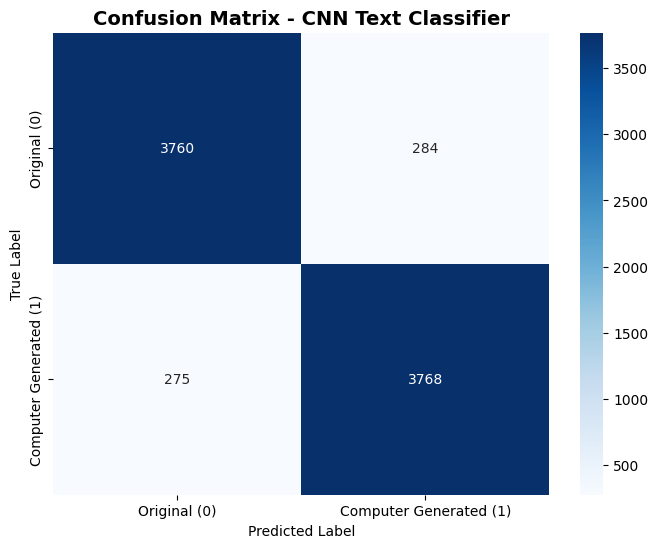


📋 Classification Report:
                        precision    recall  f1-score   support

          Original (0)       0.93      0.93      0.93      4044
Computer Generated (1)       0.93      0.93      0.93      4043

              accuracy                           0.93      8087
             macro avg       0.93      0.93      0.93      8087
          weighted avg       0.93      0.93      0.93      8087



In [17]:
# Confusion Matrix
print("📊 Confusion Matrix cho CNN:")
cm_cnn = confusion_matrix(y_test, y_cnn_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Original (0)', 'Computer Generated (1)'], 
            yticklabels=['Original (0)', 'Computer Generated (1)'])
plt.title('Confusion Matrix - CNN Text Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_cnn_pred, 
                          target_names=['Original (0)', 'Computer Generated (1)']))

## 12. Training History Visualization

📈 Vẽ biểu đồ training history...


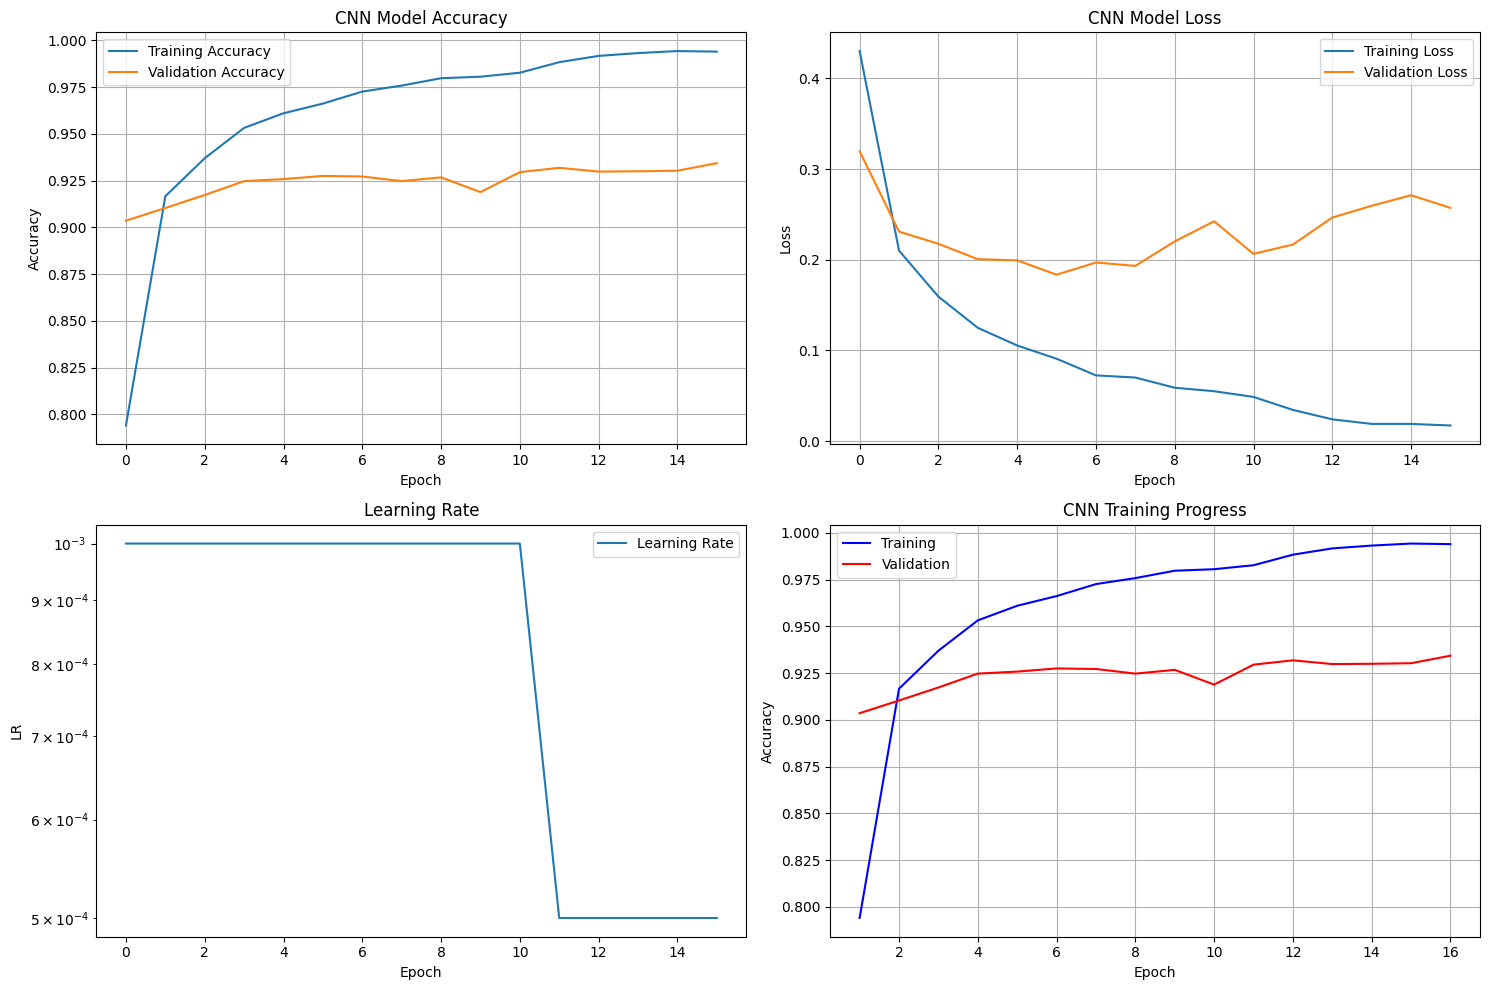

In [18]:
# Training history visualization
print("📈 Vẽ biểu đồ training history...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
if 'val_accuracy' in history.history:
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 0].set_title('CNN Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history.history['loss'], label='Training Loss')
if 'val_loss' in history.history:
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 1].set_title('CNN Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Learning Rate (nếu có)
if 'lr' in history.history:
    axes[1, 0].plot(history.history['lr'], label='Learning Rate')
    axes[1, 0].set_title('Learning Rate')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('LR')
    axes[1, 0].legend()
    axes[1, 0].set_yscale('log')

# Training Progress
epochs = range(1, len(history.history['accuracy']) + 1)
axes[1, 1].plot(epochs, history.history['accuracy'], 'b-', label='Training')
if 'val_accuracy' in history.history:
    axes[1, 1].plot(epochs, history.history['val_accuracy'], 'r-', label='Validation')
axes[1, 1].set_title('CNN Training Progress')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 13. Lưu mô hình và Tokenizer

In [19]:
# Lưu mô hình CNN
print("💾 Lưu mô hình CNN...")

# Lưu model
cnn_model.save('cnn_text_classifier_final.h5')
print("✓ CNN model saved to 'cnn_text_classifier_final.h5'")

# Lưu tokenizer
with open('cnn_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ CNN tokenizer saved to 'cnn_tokenizer.pkl'")

# Lưu label mapping
with open('cnn_label_mapping.pkl', 'wb') as f:
    pickle.dump(label_map, f)
print("✓ CNN label mapping saved to 'cnn_label_mapping.pkl'")

# Lưu preprocessing parameters
preprocessing_params = {
    'MAX_WORDS': MAX_WORDS,
    'MAX_LEN': MAX_LEN,
    'EMBEDDING_DIM': EMBEDDING_DIM
}
with open('cnn_preprocessing_params.pkl', 'wb') as f:
    pickle.dump(preprocessing_params, f)
print("✓ CNN preprocessing parameters saved to 'cnn_preprocessing_params.pkl'")

print("\n✅ All CNN components saved successfully!")

💾 Lưu mô hình CNN...
✓ CNN model saved to 'cnn_text_classifier_final.h5'
✓ CNN tokenizer saved to 'cnn_tokenizer.pkl'
✓ CNN label mapping saved to 'cnn_label_mapping.pkl'
✓ CNN preprocessing parameters saved to 'cnn_preprocessing_params.pkl'

✅ All CNN components saved successfully!


## 14. Kết luận và So sánh

In [20]:
# Final summary
print("🎯 CNN FAKE REVIEWS DETECTION - FINAL SUMMARY")
print("=" * 60)

print(f"\n📊 CNN PERFORMANCE:")
print(f"• Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
print(f"• Precision: {cnn_precision:.4f}")
print(f"• Recall: {cnn_recall:.4f}")
print(f"• F1-Score: {cnn_f1:.4f}")
if cnn_auc:
    print(f"• ROC AUC: {cnn_auc:.4f}")

print(f"\n⏱️ TIMING:")
print(f"• Training time: {training_time:.2f} seconds")
print(f"• Prediction time: {prediction_time:.4f} seconds")
print(f"• Training efficiency: {cnn_accuracy/training_time:.3f}")

print(f"\n🏗️ MODEL ARCHITECTURE:")
print(f"• Vocabulary size: {vocab_size:,}")
print(f"• Max sequence length: {MAX_LEN}")
print(f"• Embedding dimension: {EMBEDDING_DIM}")
print(f"• Total parameters: {cnn_model.count_params():,}")

print(f"\n💾 SAVED FILES:")
print(f"• CNN Model: cnn_text_classifier_final.h5")
print(f"• Tokenizer: cnn_tokenizer.pkl")
print(f"• Label Mapping: cnn_label_mapping.pkl")
print(f"• Preprocessing Params: cnn_preprocessing_params.pkl")

print(f"\n✅ CNN ANALYSIS HOÀN THÀNH!")
print(f"   Model đã được lưu và sẵn sàng sử dụng! 🚀")

🎯 CNN FAKE REVIEWS DETECTION - FINAL SUMMARY

📊 CNN PERFORMANCE:
• Accuracy: 0.9309 (93.09%)
• Precision: 0.9309
• Recall: 0.9309
• F1-Score: 0.9309
• ROC AUC: 0.9819

⏱️ TIMING:
• Training time: 2046.96 seconds
• Prediction time: 7.3723 seconds
• Training efficiency: 0.000

🏗️ MODEL ARCHITECTURE:
• Vocabulary size: 10,000
• Max sequence length: 200
• Embedding dimension: 100
• Total parameters: 1,391,617

💾 SAVED FILES:
• CNN Model: cnn_text_classifier_final.h5
• Tokenizer: cnn_tokenizer.pkl
• Label Mapping: cnn_label_mapping.pkl
• Preprocessing Params: cnn_preprocessing_params.pkl

✅ CNN ANALYSIS HOÀN THÀNH!
   Model đã được lưu và sẵn sàng sử dụng! 🚀
